Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

STAGE 1: Training Deep Learner...
Epoch 1/12
393/393 ━━━━━━━━━━━━━━━━━━━━ 200s 406ms/step - accuracy: 0.5408 - loss: 0.9646 - val_accuracy: 0.6424 - val_loss: 0.6521 - learning_rate: 2.0000e-04
Epoch 2/12
393/393 ━━━━━━━━━━━━━━━━━━━━ 0s 908ms/step - accuracy: 0.6222 - loss: 0.6659
Exception ignored in: <generator object window_generator at 0x792140176540>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/tensorflow/python/data/ops/dataset_ops.py", line 872, in iterator_completed
    del self._iterators[self._normalize_id(iterator_id)]
RuntimeError: generator ignored GeneratorExit
393/393 ━━━━━━━━━━━━━━━━━━━━ 400s 1s/step - accuracy: 0.6222 - loss: 0.6658 - val_accuracy: 0.6628 - val_loss: 0.6222 - learning_rate: 2.0000e-04
Epoch 3/12
393/393 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - accuracy: 0.7025 - loss: 0.5871
Exception ignore

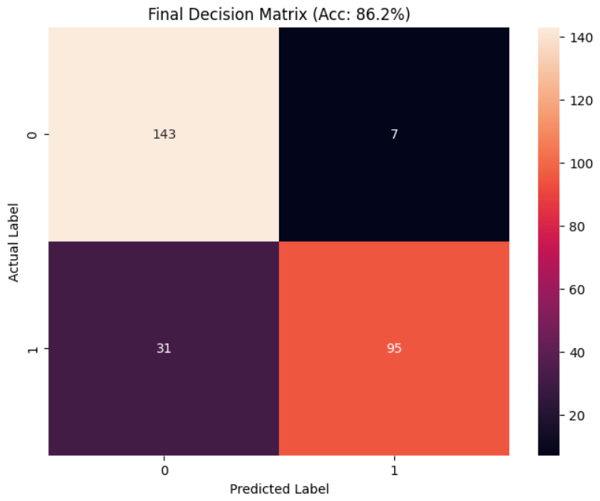

In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers, callbacks
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from scipy.stats import skew, kurtosis
from google.colab import drive

drive.mount('/content/drive')
DRIVE_BASE_DIR = '/content/drive/MyDrive/gp_dataset/preprocessing_v2'
MODEL_SAVE_DIR = '/content/drive/MyDrive/models_vfinal_90plus'
os.makedirs(MODEL_SAVE_DIR, exist_ok=True)

INPUT_SHAPE = (19, 6000)

def se_block(inputs, ratio=8):
    filters = inputs.shape[-1]
    se = layers.GlobalAveragePooling1D()(inputs)
    se = layers.Dense(filters // ratio, activation='relu')(se)
    se = layers.Dense(filters, activation='sigmoid')(se)
    return layers.Multiply()([inputs, se])

def res_block_vFinal(x, filters, stride=1):
    shortcut = x
    x = layers.Conv1D(filters, 11, strides=stride, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('swish')(x)
    x = layers.Conv1D(filters, 11, strides=1, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = se_block(x)
    if stride != 1 or shortcut.shape[-1] != filters:
        shortcut = layers.Conv1D(filters, 1, strides=stride, padding='same')(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)
    x = layers.Add()([x, shortcut])
    x = layers.Activation('swish')(x)
    return x

def build_feature_extractor():
    inputs = layers.Input(shape=INPUT_SHAPE)
    x = layers.Permute((2, 1))(inputs)
    x = layers.Conv1D(64, 31, strides=4, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('swish')(x)
    for f in [64, 128, 256, 512]:
        x = res_block_vFinal(x, f, stride=2)
        x = res_block_vFinal(x, f, stride=1)
    avg_p = layers.GlobalAveragePooling1D()(x)
    max_p = layers.GlobalMaxPooling1D()(x)
    merged = layers.Concatenate()([avg_p, max_p])
    x = layers.Dense(512, activation='swish')(merged)
    x = layers.Dropout(0.5)(x)
    feature_layer = layers.Dense(256, activation='swish', name='deep_features')(x)
    outputs = layers.Dense(1, activation='sigmoid')(feature_layer)
    return models.Model(inputs, outputs)

def get_raw_signal_features(data_19x6000):
    feats = []
    for i in range(19):
        ch = data_19x6000[i, :]
        feats.extend([np.mean(ch), np.std(ch), skew(ch), kurtosis(ch), np.max(ch)-np.min(ch)])
    zcr = np.mean([np.where(np.diff(np.sign(data_19x6000[i, :])))[0].size for i in range(19)])
    feats.append(zcr)
    return np.array(feats)

def load_paths(sub_folder):
    paths = []
    base_path = os.path.join(DRIVE_BASE_DIR, sub_folder)
    for cls_name, label in [('normal', 0), ('abnormal', 1)]:
        dir_path = os.path.join(base_path, cls_name)
        if os.path.exists(dir_path):
            files = [f for f in os.listdir(dir_path) if f.endswith('.npy')]
            for f in files: paths.append((os.path.join(dir_path, f), label))
    return paths

def window_generator(p_list):
    while True:
        idx = np.random.permutation(len(p_list))
        for i in idx:
            path, label = p_list[i]
            try:
                data = np.load(path)
                for w in data: yield w, label
            except: continue

def create_ds(p_list, batch=32):
    return tf.data.Dataset.from_generator(
        lambda: window_generator(p_list),
        output_signature=(tf.TensorSpec(shape=INPUT_SHAPE, dtype=tf.float32), tf.TensorSpec(shape=(), dtype=tf.int32))
    ).batch(batch).prefetch(tf.data.AUTOTUNE)

train_paths_all = load_paths('train')
test_paths_all = load_paths('eval')
train_p, val_p = train_test_split(train_paths_all, test_size=0.1, random_state=42, stratify=[p[1] for p in train_paths_all])

resnet = build_feature_extractor()
resnet.compile(optimizer=tf.keras.optimizers.AdamW(2e-4), loss='binary_crossentropy', metrics=['accuracy'])

print("\nSTAGE 1: Training Deep Learner...")
resnet.fit(create_ds(train_p), validation_data=create_ds(val_p), epochs=12,
           steps_per_epoch=len(train_p)*10//32, validation_steps=len(val_p)*10//32,
           callbacks=[callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3),
                      callbacks.EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)])

def extract_patient_features(model, p_list):
    feat_extractor = models.Model(inputs=model.input, outputs=model.get_layer('deep_features').output)
    X, y = [], []
    for path, label in tqdm(p_list, desc="Patient Feature Extraction"):
        try:
            windows = np.load(path)
            probs = model.predict(windows, verbose=0).flatten()
            p_stats = [np.mean(probs), np.max(probs), np.std(probs), np.median(probs), np.sort(probs)[-2] if len(probs)>1 else probs[0]]
            d_feats = feat_extractor.predict(windows, verbose=0)
            d_stats = np.concatenate([np.mean(d_feats, axis=0), np.max(d_feats, axis=0)])
            r_stats = get_raw_signal_features(windows[0])

            X.append(np.concatenate([d_stats, p_stats, r_stats]))
            y.append(label)
        except: continue
    return np.array(X), np.array(y)

print("\nSTAGE 2: Harvesting Patient-Level Data...")
X_train, y_train = extract_patient_features(resnet, train_paths_all)
X_test, y_test = extract_patient_features(resnet, test_paths_all)

print("\nSTAGE 3: Training Final CatBoost & Optimizing Threshold...")
clf = CatBoostClassifier(iterations=2000, learning_rate=0.01, depth=8, l2_leaf_reg=20,
                         eval_metric='F1', auto_class_weights='Balanced', early_stopping_rounds=200, verbose=100)
clf.fit(X_train, y_train, eval_set=(X_test, y_test))

y_proba = clf.predict_proba(X_test)[:, 1]
best_t = 0.5
best_acc = 0
for t in np.arange(0.3, 0.7, 0.01):
    acc = accuracy_score(y_test, (y_proba > t).astype(int))
    if acc > best_acc:
        best_acc, best_t = acc, t

y_pred_final = (y_proba > best_t).astype(int)

print("\n" + "="*60)
print(f"FINAL CLINICAL REPORT (Optimized T: {best_t:.2f})")
print("="*60)
print(f"Final Patient Accuracy: {best_acc*100:.2f}%")
print(f"Final Patient AUC:      {roc_auc_score(y_test, y_proba):.4f}")
print("\n", classification_report(y_test, y_pred_final, target_names=['Normal', 'Abnormal']))

resnet.save(f"{MODEL_SAVE_DIR}/resnet_final.keras")
clf.save_model(f"{MODEL_SAVE_DIR}/cat_final.bin")

plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred_final), annot=True, fmt='d', cmap='rocket')
plt.title(f'Final Decision Matrix (Acc: {best_acc*100:.1f}%)')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

Mounted at /content/drive

STAGE 1: Training Ultimate Hybrid (Bidirectional)...
Epoch 1/30
393/393 ━━━━━━━━━━━━━━━━━━━━ 80s 189ms/step - accuracy: 0.5304 - loss: 0.9364 - val_accuracy: 0.6432 - val_loss: 0.6188 - learning_rate: 1.0000e-04
Epoch 2/30
393/393 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step - accuracy: 0.5534 - loss: 0.9017
Exception ignored in: <generator object fast_patient_generator at 0x7f95302715d0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/tensorflow/python/data/ops/dataset_ops.py", line 872, in iterator_completed
    del self._iterators[self._normalize_id(iterator_id)]
RuntimeError: generator ignored GeneratorExit
393/393 ━━━━━━━━━━━━━━━━━━━━ 143s 364ms/step - accuracy: 0.5534 - loss: 0.9017 - val_accuracy: 0.6984 - val_loss: 0.6079 - learning_rate: 1.0000e-04
Epoch 3/30
393/393 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.5873 - loss: 0.8405
Exception ignored in: <generator object fast_patient_generator at 0x7f9530273010>
Traceback 

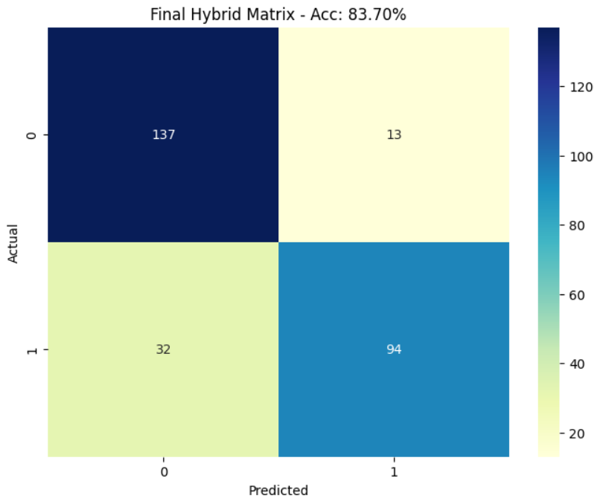

In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers, callbacks
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from google.colab import drive

drive.mount('/content/drive', force_remount=True)
DRIVE_BASE_DIR = '/content/drive/MyDrive/gp_dataset/preprocessing_v2'
MODEL_SAVE_DIR = '/content/drive/MyDrive/models_hybrid_vFinal_PRO'
os.makedirs(MODEL_SAVE_DIR, exist_ok=True)

INPUT_SHAPE = (19, 6000)

def build_bidirectional_hybrid():
    inputs = layers.Input(shape=INPUT_SHAPE)
    x = layers.Permute((2, 1))(inputs) 

    x = layers.Conv1D(64, 31, strides=4, padding='same', kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('swish')(x)
    x = layers.MaxPooling1D(2)(x)

    x = layers.Conv1D(128, 15, strides=2, padding='same', kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('swish')(x)
    x = layers.MaxPooling1D(2)(x)

    x = layers.Bidirectional(layers.GRU(128, return_sequences=False, dropout=0.3))(x)

    x = layers.Dense(64, activation='swish')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    return models.Model(inputs, outputs)

def load_paths(sub_folder):
    paths = []
    base_path = os.path.join(DRIVE_BASE_DIR, sub_folder)
    for cls_name, label in [('normal', 0), ('abnormal', 1)]:
        dir_path = os.path.join(base_path, cls_name)
        if os.path.exists(dir_path):
            files = [f for f in os.listdir(dir_path) if f.endswith('.npy')]
            for f in files: paths.append((os.path.join(dir_path, f), label))
    return paths

def fast_patient_generator(p_list):
    while True:
        np.random.shuffle(p_list)
        for path, label in p_list:
            try:
                data = np.load(path)
                if data.ndim == 3:
                    for w in data: yield w, label
            except: continue

def create_dataset(p_list, batch=32):
    ds = tf.data.Dataset.from_generator(
        lambda: fast_patient_generator(p_list),
        output_signature=(tf.TensorSpec(shape=INPUT_SHAPE, dtype=tf.float32), tf.TensorSpec(shape=(), dtype=tf.int32))
    )
    return ds.repeat().batch(batch).prefetch(tf.data.AUTOTUNE)

train_paths = load_paths('train')
eval_paths = load_paths('eval')
train_p, val_p = train_test_split(train_paths, test_size=0.1, random_state=42, stratify=[p[1] for p in train_paths])

hybrid_pro = build_bidirectional_hybrid()
hybrid_pro.compile(optimizer=tf.keras.optimizers.Adam(1e-4), loss='binary_crossentropy', metrics=['accuracy'])

class_weights = {0: 1.0, 1: 1.8}

callbacks_list = [
    callbacks.ModelCheckpoint(f"{MODEL_SAVE_DIR}/best_hybrid_pro.keras", save_best_only=True, monitor='val_accuracy'),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1),
    callbacks.EarlyStopping(monitor='val_accuracy', patience=8, restore_best_weights=True)
]

print("\n STAGE 1: Training Ultimate Hybrid (Bidirectional)...")
history = hybrid_pro.fit(
    create_dataset(train_p),
    validation_data=create_dataset(val_p),
    epochs=30,
    steps_per_epoch=(len(train_p) * 10) // 32,
    validation_steps=(len(val_p) * 10) // 32,
    class_weight=class_weights,
    callbacks=callbacks_list,
    verbose=1
)

def evaluate_patients_pro(model, p_list):
    y_true, y_probs = [], []
    for path, label in tqdm(p_list, desc="Deep Evaluation"):
        try:
            windows = np.load(path)
            probs = model.predict(windows, verbose=0).flatten()

            patient_score = np.percentile(probs, 70)
            y_probs.append(patient_score)
            y_true.append(label)
        except: continue

    y_true = np.array(y_true)
    y_probs = np.array(y_probs)

    best_acc, best_t = 0, 0.5
    for t in np.linspace(0.1, 0.9, 200):
        acc = accuracy_score(y_true, (y_probs > t).astype(int))
        if acc >= best_acc:
            best_acc = acc
            best_t = t

    return y_true, (y_probs > best_t).astype(int), y_probs, best_t

print("\nSTAGE 2: Final Performance Analysis...")
y_true, y_pred, y_probs, final_t = evaluate_patients_pro(hybrid_pro, eval_paths)

print("\n" + "="*60)
print(f"RESULTS (Threshold: {final_t:.4f})")
print("="*60)
final_acc = accuracy_score(y_true, y_pred)
print(f"Accuracy: {final_acc*100:.2f}%")
print(f"ROC AUC:  {roc_auc_score(y_true, y_probs):.4f}")
print("\n", classification_report(y_true, y_pred, target_names=['Normal', 'Abnormal']))

with open(f"{MODEL_SAVE_DIR}/pro_report.txt", "w") as f:
    f.write(f"Accuracy: {final_acc*100:.2f}%\nROC AUC: {roc_auc_score(y_true, y_probs):.4f}\n")
    f.write(classification_report(y_true, y_pred))

plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_true, y_pred), annot=True, fmt='d', cmap='YlGnBu')
plt.title(f'Final Hybrid Matrix - Acc: {final_acc*100:.2f}%')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig(f"{MODEL_SAVE_DIR}/pro_matrix.png")
plt.show()